In [ ]:
# lets import the requirements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [3]:
# lets import the data
df = pd.read_csv("processed_data.csv")
df.head()

,Unnamed: 0,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
0,0,oh gosh,3,1.945910,0.693147,0.693147,1.386294
1,1,trouble sleeping confused mind restless heart ...,3,3.912023,1.945910,1.945910,1.945910
2,2,wrong back dear forward doubt stay restless re...,3,4.060443,2.197225,2.079442,1.791759
3,3,shifted focus something else still worried,3,3.737670,1.791759,1.791759,1.945910
4,4,restless restless month boy mean,3,3.465736,1.609438,1.386294,1.791759


In [5]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [6]:
# --> here we are gonna focus on working with the balanced data and try hypeparamter tunning of major models 
# ---> we try -balanced logitic regression 
#             - balanced random forest with tunning
#             - tunning of gradient boosting and work with adavce models like lightgbm


In [8]:
# lets make a split of data 
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop(columns="status"),df["status"],test_size=0.2,stratify=df["status"],random_state=1)


In [9]:
print(xtrain.shape)

(42036, 5)


In [20]:
# here we use the tfidf for text encoding as this outperforms the bag of words
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(), "clean_text"),   # preprocessed text
    ("num", StandardScaler(), num_cols)             # numeric features
])


In [21]:
# lets make a pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])



In [26]:
# lets make the parameter grid

param_dist = {
    # TF-IDF
    "preprocess__text__max_features": [10000,15000,20000],
    "preprocess__text__ngram_range": [(1,1), (1,2)],
    "preprocess__text__max_df": [0.8, 0.9, 1.0],
    
    
    # Logistic Regression
    "model__C": [0.1,1,2,5,10],
    "model__solver":["saga"]
}



In [27]:
# lets make the random search object
from sklearn.model_selection import RandomizedSearchCV
# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,                
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2,
    random_state=42
)



In [28]:
# lets fit it on our data
random_search.fit(xtrain, ytrain)



Fitting 2 folds for each of 30 candidates, totalling 60 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(),
                                                                               'clean_text'),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['statement_length',
                                                                                'num_words',
                                                                                'vocabulary_size',
                                                                                'avg_word_length'])])),
                                             ('model',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=3000))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__C': [0.1, 1, 2, 5, 10],
                                        'model__solver': ['saga'],
                                        'preprocess__text__max_df': [0.8, 0.9,
                                                                     1.0],
                                        'preprocess__text__max_features': [10000,
                                                                           15000,
                                                                           20000],
                                        'preprocess__text__ngram_range': [(1,
                                                                           1),
                                                                          (1,
                                                                           2)]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [29]:
# Best params
print("Best Params:\n", random_search.best_params_)
print("Best CV Score (F1-weighted):", random_search.best_score_)

Best Params:
 {'preprocess__text__ngram_range': (1, 2), 'preprocess__text__max_features': 20000, 'preprocess__text__max_df': 0.9, 'model__solver': 'saga', 'model__C': 5}
Best CV Score (F1-weighted): 0.7582379153521706


In [30]:
# here from my testing and tunning the and other research on this data logistic reagression can only goes to 0.76 f1weighted 
# so now lets test our model and see the precison and recall values there must be improvemnet 
# from the simple logistic regression modell without balancing the class weights

In [31]:
# here the best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(xtest)

Accuracy: 0.7618231991626225
classification report 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      3243
           1       0.76      0.62      0.69      3081
           2       0.64      0.72      0.68      2129
           3       0.77      0.82      0.80       768
           4       0.78      0.83      0.81       555
           5       0.52      0.68      0.59       518
           6       0.62      0.76      0.68       215

    accuracy                           0.76     10509
   macro avg       0.71      0.76      0.73     10509
weighted avg       0.77      0.76      0.76     10509



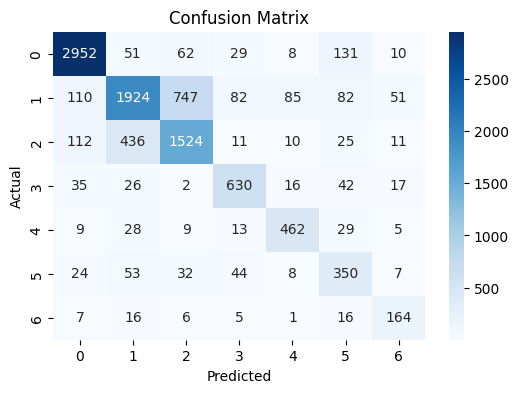

In [32]:
# lets understand the model report
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


acc = accuracy_score(ytest, y_pred)
print("Accuracy:", acc)
print("classification report \n",classification_report(ytest, y_pred))

# confusion matrix plot
cm = confusion_matrix(ytest, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 📊 Model Comparison Report: Balanced vs Non-Balanced Logistic Regression

---

## 🔹 1. Overall Performance Comparison

| Metric            | Balanced Model | Non-Balanced Model |
|------------------|---------------|--------------------|
| Accuracy         | 0.76          | 0.76               |
| Macro F1-score   | **0.73 ✅**   | **0.71 ❌**        |
| Weighted F1-score| 0.76          | 0.76               |

### 🧠 Observation:
- Accuracy remains **unchanged**
- Macro F1 improves → **better fairness across classes**
- Weighted F1 same → overall performance similar

---

## 🔹 2. Class-wise Comparison

### 📊 Detailed Metrics Table

| Class | Support | Precision (Balanced) | Recall (Balanced) | F1 (Balanced) | Precision (Non-Balanced) | Recall (Non-Balanced) | F1 (Non-Balanced) |
|------|--------|--------------------|------------------|--------------|--------------------------|----------------------|------------------|
| 0 | 3243 | 0.91 | 0.91 | 0.91 | 0.87 | 0.95 | 0.91 |
| 1 | 3081 | 0.76 | 0.62 | 0.69 | 0.68 | 0.74 | 0.71 |
| 2 | 2129 | 0.64 | 0.72 | 0.68 | 0.67 | 0.64 | 0.65 |
| 3 | 768  | 0.77 | 0.82 | 0.80 | 0.81 | 0.74 | 0.77 |
| 4 | 555  | 0.78 | 0.83 | 0.81 | 0.88 | 0.72 | 0.79 |
| 5 | 518  | 0.52 | 0.68 | 0.59 | 0.69 | 0.45 | 0.55 |
| 6 | 215  | 0.62 | 0.76 | 0.68 | 0.84 | 0.47 | 0.60 |

---

## 🔥 3. Key Differences & Insights

---

### ✅ Minority Classes (5 & 6) — Major Improvement

#### Class 6 (Most critical case)
- Recall: **0.47 → 0.76 🔥**
- F1-score: **0.60 → 0.68**

👉 Interpretation:
- Balanced model **detects more actual cases**
- Non-balanced model **misses many true cases**

---

#### Class 5
- Recall: **0.45 → 0.68 🔥**
- F1-score: **0.55 → 0.59**

👉 Improvement in detecting rare cases

---

### ⚠️ Majority Classes — Slight Trade-off

#### Class 1
- Recall: **0.74 → 0.62 ❌**
- Precision: **0.68 → 0.76 ✅**

👉 Model becomes:
- More selective  
- But misses some actual cases  

---

#### Class 0
- Recall drops slightly: **0.95 → 0.91**

👉 Small trade-off, still strong performance

---

## ⚖️ 4. Trade-off Analysis (VERY IMPORTANT)

---

### 🔹 Non-Balanced Model

✔ High precision for most classes  
✔ Strong performance on majority classes  

❌ Poor recall for minority classes  
❌ Biased predictions  

👉 Behavior:
Conservative model → predicts majority classes more


---

### 🔹 Balanced Model

✔ High recall for minority classes 🔥  
✔ More fair predictions  
✔ Better macro F1  

❌ Slight drop in precision  
❌ Slight drop in majority class recall  

👉 Behavior:
Aggressive model → predicts minority classes more


---

## 💡 5. Precision vs Recall Trade-off

---

### What changed?

| Aspect | Effect |
|-------|-------|
| Precision ↓ | More false positives |
| Recall ↑ | Fewer missed cases |

---

### 🧠 Interpretation:

👉 Balanced model says:

"I would rather predict more cases (even if some are wrong)
than miss important cases"



---

## 🎯 6. Business / Real-world Impact

---

### ✅ Balanced Model (Recommended)

Best for:
- Mental health detection 🔥  
- Medical diagnosis  
- Fraud detection  

👉 Why?
Missing a true case is dangerous



---

### ❌ Non-Balanced Model

Best for:
- Spam filtering  
- Recommendation systems  

👉 Why?

Precision is more important than recall


---

## 📈 7. Why Macro F1 Improved

- Macro F1 treats all classes equally
- Balanced model improved:

0.71 → 0.73


👉 Meaning:Better performance across ALL classes


---

## 🧠 8. Final Interpretation

---

### Balanced Model

✔ Fair across all classes  
✔ Strong minority detection  
✔ Better real-world applicability  

---

### Non-Balanced Model

✔ Better precision for majority classes  
❌ Poor minority detection  
❌ Biased predictions  

---

## 🎯 9. Final Conclusion

> Although both models achieve similar accuracy (~76%), the balanced model significantly improves recall for minority classes and increases macro F1-score. This indicates a more fair and robust model. The trade-off is a slight reduction in precision and majority class recall. For applications like mental health classification, where missing critical cases is unacceptable, the balanced model is clearly the better choice.

---

## 🚀 10. Key Takeaway
Accuracy stayed same
But model behavior changed completely 🔥
